# Ранжирование BM25 и оценка результатов поиска

In [4]:
!pip install -q rank_bm25 ir_measures
!python -m spacy download en_core_web_sm -q

from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/hw_2')  # подставить свой путь

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 45.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 0. Подготовка

In [ ]:
import os, time, random, math
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import nltk
from nltk.stem.porter import PorterStemmer
import spacy

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from rank_bm25 import BM25Okapi

import ir_measures
from ir_measures import P, MAP, nDCG, read_trec_qrels

DATA_DIR  = 'wikIR1k'
DOCS_CSV  = 'documents.csv'

## 1. Базовая статистика тестовых запросов

* запросы хранятся в `queries.csv` (id_left, text_left)

* релевантность — в `qrels` (TREC-формат: qid 0 docid rel).

In [6]:
def load_queries(path):
    df = pd.read_csv(path)
    assert list(df.columns) == ['id_left', 'text_left'], df.columns
    return {str(i): t for i, t in zip(df['id_left'], df['text_left'])}

def load_qrels_dict(path):
    out = defaultdict(dict)
    with open(path) as f:
        for line in f:
            qid, _, did, rel = line.split()
            out[qid][did] = int(rel)
    return dict(out)

test_queries = load_queries(f'{DATA_DIR}/test/queries.csv')
val_queries  = load_queries(f'{DATA_DIR}/validation/queries.csv')
test_qrels   = load_qrels_dict(f'{DATA_DIR}/test/qrels')
val_qrels    = load_qrels_dict(f'{DATA_DIR}/validation/qrels')

qlens_test = np.array([len(t.split()) for t in test_queries.values()])
nrel_test  = np.array([len(test_qrels.get(q, {})) for q in test_queries])

print(f'# test queries               : {len(test_queries)}')
print(f'# validation queries         : {len(val_queries)}')
print(f'query length (words)         : min={qlens_test.min()}, median={np.median(qlens_test):.0f}, '
      f'mean={qlens_test.mean():.2f}, max={qlens_test.max()}')
print(f'# relevant docs per query    : min={nrel_test.min()}, median={np.median(nrel_test):.0f}, '
      f'mean={nrel_test.mean():.1f}, max={nrel_test.max()}')
print(f'# queries with rel=2 docs    : {sum(2 in r.values() for r in test_qrels.values())}')

# test queries               : 100
# validation queries         : 100
query length (words)         : min=1, median=2, mean=2.07, max=9
# relevant docs per query    : min=6, median=9, mean=44.4, max=2759
# queries with rel=2 docs    : 100


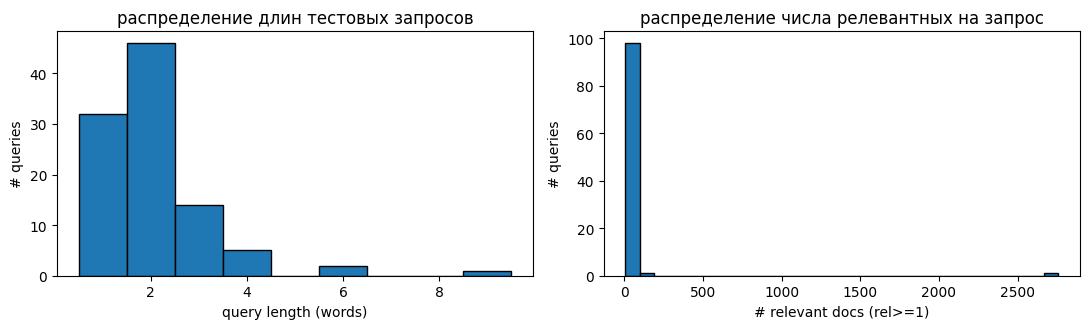

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].hist(qlens_test, bins=range(1, qlens_test.max()+2), edgecolor='k', align='left')
axes[0].set_xlabel('query length (words)')
axes[0].set_ylabel('# queries')
axes[0].set_title('распределение длин тестовых запросов')

axes[1].hist(nrel_test, bins=30, edgecolor='k')
axes[1].set_xlabel('# relevant docs (rel>=1)')
axes[1].set_ylabel('# queries')
axes[1].set_title('распределение числа релевантных на запрос')
plt.tight_layout(); plt.show()

Тестовая выборка — 100 коротких запросов (1-9 слов, медиана 2). На запрос в qrels в среднем 44 релевантных документа (медиана 9, максимум 2759), у всех 100 запросов есть документ с rel=2.

Запрос — название или первое предложение статьи, релевантный документ — сама статья (rel=2) плюс документы, ссылающиеся на неё (rel=1).

## 2. Поиск на трёх вариантах коллекции

Запускаем tf-idf и Rank-BM25 на трёх версиях коллекции:

* оригинал
* стемминг
* лемматизация


In [8]:
def load_docs(path):
    ids, docs = [], []
    with open(path, 'r', encoding='utf-8') as f:
        next(f)  # header
        for line in f:
            i = line.find(',')
            ids.append(line[:i])
            docs.append(line[i+1:].rstrip('\n').split())
    return ids, docs

doc_ids, docs_orig = load_docs(DOCS_CSV)
print(f'loaded {len(doc_ids):,} docs')

doc_id_to_pos = {d: i for i, d in enumerate(doc_ids)}

loaded 369,721 docs


### 2.1 Стеммер Портер

Cтеммер не зависит от контекста — кэшируем его вывод на словарь и применяем к документам.

In [9]:
stemmer = PorterStemmer()
vocab = set()
for d in docs_orig:
    vocab.update(d)
print(f'vocab size: {len(vocab):,}')
t0 = time.time()
stem_map = {w: stemmer.stem(w) for w in tqdm(vocab, desc='Porter stem')}
docs_stem = [[stem_map[w] for w in d] for d in tqdm(docs_orig, desc='apply stem')]
print(f'stemmed in {time.time()-t0:.1f}s; unique stems: {len(set(stem_map.values())):,}')

vocab size: 794,568


Porter stem:   0%|          | 0/794568 [00:00<?, ?it/s]

apply stem:   0%|          | 0/369721 [00:00<?, ?it/s]

stemmed in 54.2s; unique stems: 684,579


### 2.2 Лемматизация

In [10]:
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
vocab = list({w for d in docs_orig for w in d})
print(f'lemmatizing {len(vocab):,} unique words...')
t0 = time.time()
lemma_map = {}
for w, doc in tqdm(zip(vocab, nlp.pipe(vocab, batch_size=1024)),
                   total=len(vocab), desc='spaCy lemma'):
    lemma_map[w] = doc[0].lemma_ if len(doc) > 0 else w
docs_lemma = [[lemma_map[w] for w in d] for d in tqdm(docs_orig, desc='apply lemma')]
print(f'lemmatized in {time.time()-t0:.1f}s; unique lemmas: {len(set(lemma_map.values())):,}')

lemmatizing 794,568 unique words...


spaCy lemma:   0%|          | 0/794568 [00:00<?, ?it/s]

apply lemma:   0%|          | 0/369721 [00:00<?, ?it/s]

loaded lemmatized docs (794,568 words in map)


### 2.3 Функции поиска

Для каждого варианта коллекции строим две структуры:

* sklearn TfidfVectorizer (с нормализацией l2 = косинус)
* Rank-BM25 (дефолтные k1=1.5, b=0.75)

Запрос обрабатываем теми же преобразованиями, что и документы.

In [11]:
TOP_K = 1000

def identity(x):
    return x

def build_tfidf(docs):
    vec = TfidfVectorizer(analyzer=identity, preprocessor=identity,
                          token_pattern=None, lowercase=False, norm='l2')
    X = vec.fit_transform(docs)
    return vec, X

def search_tfidf(vec, X, q_tokens, top_k=TOP_K):
    q = vec.transform([q_tokens])  # sparse 1 x V
    if q.nnz == 0:
        return np.array([], dtype=np.int64), np.array([])
    scores = (X @ q.T).toarray().ravel()
    k = min(top_k, scores.size)
    idx = np.argpartition(-scores, k-1)[:k]
    idx = idx[np.argsort(-scores[idx])]
    idx = idx[scores[idx] > 0]
    return idx, scores[idx]

def search_bm25(bm25, q_tokens, top_k=TOP_K):
    scores = bm25.get_scores(q_tokens)
    k = min(top_k, scores.size)
    idx = np.argpartition(-scores, k-1)[:k]
    idx = idx[np.argsort(-scores[idx])]
    idx = idx[scores[idx] > 0]
    return idx, scores[idx]

def rankings_to_run(rankings, doc_ids):
    out = []
    for qid, (idx, sc) in rankings.items():
        for i, s in zip(idx, sc):
            out.append(ir_measures.ScoredDoc(qid, doc_ids[i], float(s)))
    return out

In [12]:
VARIANTS = {
    'original':   (docs_orig,  None),
    'stemmed':    (docs_stem,  stem_map),
    'lemmatized': (docs_lemma, lemma_map),
}

def process_query(raw_q, mapping):
    toks = raw_q.split()
    if mapping is None:
        return toks
    return [mapping.get(w, w) for w in toks]

build_times, index_sizes = {}, {}
tfidf_indexes, bm25_indexes = {}, {}

for name, (docs, mapping) in VARIANTS.items():
    t0 = time.time()
    vec, X = build_tfidf(docs)
    t_tfidf = time.time() - t0
    t0 = time.time()
    bm25 = BM25Okapi(docs)
    t_bm25 = time.time() - t0
    tfidf_indexes[name] = (vec, X)
    bm25_indexes[name]  = bm25
    build_times[name]   = (t_tfidf, t_bm25)
    index_sizes[name]   = X.shape[1]
    print(f'{name:<11}  tfidf build {t_tfidf:6.1f}s  bm25 build {t_bm25:6.1f}s  vocab {X.shape[1]:>8,}')

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:523: UserWarning: The parameter 'preprocessor' will not be used since 'analyzer' is callable'
  warnings.warn(


original     tfidf build   48.8s  bm25 build   34.0s  vocab  794,568
stemmed      tfidf build   46.9s  bm25 build   32.3s  vocab  684,579
lemmatized   tfidf build   51.8s  bm25 build   35.8s  vocab  736,474


In [13]:
def run_all_queries(queries, variant_name, search_fn, index):
    mapping = VARIANTS[variant_name][1]
    rankings, timings = {}, []
    for qid, raw in queries.items():
        qtoks = process_query(raw, mapping)
        t0 = time.time()
        idx, sc = search_fn(index, qtoks)
        timings.append(time.time() - t0)
        rankings[qid] = (idx, sc)
    return rankings, np.array(timings)

runs = {}           # (method, variant) -> list[ir_measures.ScoredDoc]
query_times = {}
for variant in VARIANTS:
    vec, X = tfidf_indexes[variant]
    r, t = run_all_queries(test_queries, variant, lambda idx, q: search_tfidf(*idx, q), (vec, X))
    runs[('tfidf', variant)] = rankings_to_run(r, doc_ids)
    query_times[('tfidf', variant)] = t

    bm25 = bm25_indexes[variant]
    r, t = run_all_queries(test_queries, variant, search_bm25, bm25)
    runs[('bm25', variant)] = rankings_to_run(r, doc_ids)
    query_times[('bm25', variant)] = t

print(f'\n{"method":<8}{"variant":<14}{"mean ms/query":>16}{"median ms":>14}{"max ms":>12}')
for (m, v), t in query_times.items():
    tm = t * 1000
    print(f'{m:<8}{v:<14}{tm.mean():>16.1f}{np.median(tm):>14.1f}{tm.max():>12.1f}')


method  variant          mean ms/query     median ms      max ms
tfidf   original                 297.0         265.3       453.7
bm25    original                 387.8         317.2      2240.8
tfidf   stemmed                  318.4         248.2      2168.0
bm25    stemmed                  323.7         274.1      1157.8
tfidf   lemmatized               281.9         254.9       417.0
bm25    lemmatized               327.1         281.9      1183.8


## 3. Оценка runs с помощью ir-measures

Метрики и их параметры:
* P@k — доля релевантных (rel >= 1) среди топ-k; используем k = 1, 10, 20.
* MAP — среднее AP по запросам; релевантность считается бинарно (rel >= 1).
* nDCG@k — k = 20;

In [14]:
MEASURES = [P@1, P@10, P@20, MAP, nDCG@20]

qrels_list = list(read_trec_qrels(f'{DATA_DIR}/test/qrels'))

results = []
for method in ['tfidf', 'bm25']:
    for variant in VARIANTS:
        scores = ir_measures.calc_aggregate(MEASURES, qrels_list, runs[(method, variant)])
        row = {'method': method, 'variant': variant}
        for m in MEASURES:
            row[str(m)] = scores[m]
        results.append(row)

res_df = pd.DataFrame(results).set_index(['method', 'variant'])
print(res_df.round(4).to_string())

                    P@1   P@10    P@20      AP  nDCG@20
method variant                                         
tfidf  original    0.51  0.203  0.1350  0.1655   0.3499
       stemmed     0.50  0.194  0.1285  0.1595   0.3354
       lemmatized  0.52  0.199  0.1305  0.1625   0.3447
bm25   original    0.49  0.212  0.1500  0.1752   0.3570
       stemmed     0.49  0.209  0.1455  0.1742   0.3540
       lemmatized  0.49  0.210  0.1465  0.1769   0.3571


## 4. Анализ

Смотрим на:

* сложные и лёгкие запросы
* влияние длины запроса
* влияние морфологии
* попарные корреляции метрик
* нерелевантный топ

In [ ]:
# per-query scores for BM25 on original collection (our "baseline" system)
PER_QRY_MEASURES = [P@10, MAP, nDCG@20]

def per_query(run_list, measures, qrels=qrels_list):
    out = defaultdict(dict)
    for row in ir_measures.iter_calc(measures, qrels, run_list):
        out[row.query_id][str(row.measure)] = row.value
    return pd.DataFrame.from_dict(out, orient='index').fillna(0.0)

pq_bm25 = per_query(runs[('bm25', 'original')], PER_QRY_MEASURES)
pq_bm25['query']    = pq_bm25.index.map(test_queries)
pq_bm25['qlen']     = pq_bm25['query'].str.split().map(len)
pq_bm25['n_rel']    = pq_bm25.index.map(lambda q: len(test_qrels.get(q, {})))
print('10 easiest queries (highest nDCG@20):')
print(pq_bm25.sort_values('nDCG@20', ascending=False).head(10)[['query','qlen','n_rel','nDCG@20','AP']].to_string())
print('\n10 hardest queries (lowest nDCG@20):')
print(pq_bm25.sort_values('nDCG@20', ascending=True ).head(10)[['query','qlen','n_rel','nDCG@20','AP']].to_string())

10 easiest queries (highest nDCG@20):
                     query  qlen  n_rel   nDCG@20        AP
75295   dave matthews band     3      8  0.849280  0.680775
267973      gambela region     2      8  0.822220  0.598958
113000             sulfide     1      6  0.748263  0.532275
14410                  xml     1     28  0.730094  0.394131
104086             bulacan     1     10  0.716428  0.445832
8140      michael moorcock     2      8  0.658935  0.373512
121384          supertramp     1      8  0.654766  0.564583
87686              evesham     1      7  0.646022  0.506349
62953        kalmar county     2      6  0.641780  0.337745
37743            ulverston     1      6  0.629461  0.295455

10 hardest queries (lowest nDCG@20):
                                      query  qlen  n_rel   nDCG@20        AP
83078                         pomacentridae     1      8  0.000000  0.000000
738573                 television presenter     2     59  0.000000  0.004866
1897191                          

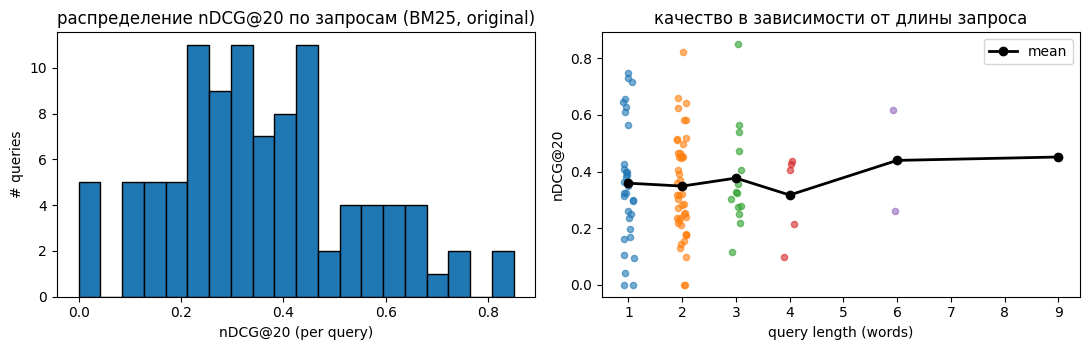

      count   mean  median
qlen                      
1        32  0.359   0.337
2        46  0.348   0.319
3        14  0.377   0.325
4         5  0.317   0.404
6         2  0.439   0.439
9         1  0.451   0.451


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].hist(pq_bm25['nDCG@20'], bins=20, edgecolor='k')
axes[0].set_xlabel('nDCG@20 (per query)'); axes[0].set_ylabel('# queries')
axes[0].set_title('распределение nDCG@20 по запросам (BM25, original)')

for qlen, grp in pq_bm25.groupby('qlen'):
    axes[1].scatter(np.full(len(grp), qlen) + np.random.uniform(-0.1, 0.1, len(grp)),
                    grp['nDCG@20'], alpha=0.6, s=20)
means = pq_bm25.groupby('qlen')['nDCG@20'].mean()
axes[1].plot(means.index, means.values, '-o', color='k', lw=2, label='mean')
axes[1].set_xlabel('query length (words)'); axes[1].set_ylabel('nDCG@20')
axes[1].set_title('качество в зависимости от длины запроса')
axes[1].legend()
plt.tight_layout(); plt.show()

print(pq_bm25.groupby('qlen')['nDCG@20'].agg(['count','mean','median']).round(3).to_string())

In [ ]:
pq_orig  = per_query(runs[('bm25', 'original')],   [nDCG@20])
pq_stem  = per_query(runs[('bm25', 'stemmed')],    [nDCG@20])
pq_lemma = per_query(runs[('bm25', 'lemmatized')], [nDCG@20])

delta = pd.DataFrame({
    'original':   pq_orig['nDCG@20'],
    'stemmed':    pq_stem['nDCG@20'],
    'lemmatized': pq_lemma['nDCG@20'],
}).fillna(0.0)
delta['stem - orig']  = delta['stemmed']    - delta['original']
delta['lemma - orig'] = delta['lemmatized'] - delta['original']
delta['query'] = delta.index.map(test_queries)

wins_stem  = (delta['stem - orig']  > 0.01).sum()
loses_stem = (delta['stem - orig']  < -0.01).sum()
wins_lemma = (delta['lemma - orig'] > 0.01).sum()
loses_lemma= (delta['lemma - orig'] < -0.01).sum()

print(f'stem vs original (BM25): {wins_stem} queries better, {loses_stem} worse, '
      f'rest unchanged or small change (threshold 0.01)')
print(f'lemma vs original:       {wins_lemma} queries better, {loses_lemma} worse')

print('\nTop gains from stemming:')
print(delta.sort_values('stem - orig', ascending=False).head(5)[['query','original','stemmed','stem - orig']].to_string())
print('\nTop losses from stemming:')
print(delta.sort_values('stem - orig', ascending=True ).head(5)[['query','original','stemmed','stem - orig']].to_string())

stem vs original (BM25): 10 queries better, 18 worse, rest unchanged or small change (threshold 0.01)
lemma vs original:       10 queries better, 10 worse

Top gains from stemming:
                                                query  original   stemmed  stem - orig
28485                        california state route 1  0.215610  0.431220     0.215610
207224  chief of staff of the united states air force  0.451214  0.623885     0.172671
139082                             roadrunner records  0.143740  0.265498     0.121758
16952                                   nelly furtado  0.360622  0.468639     0.108017
6984                                      king arthur  0.211216  0.299924     0.088708

Top losses from stemming:
                                 query  original   stemmed  stem - orig
73752                   jackson browne  0.234352  0.000000    -0.234352
32559                     yes minister  0.515661  0.317821    -0.197840
104453     uniting church in australia  0.427407  0.28

In [ ]:
# корреляция между метриками
pq_all = per_query(runs[('bm25', 'original')], MEASURES)
print('Per-query correlation between measures (Spearman):')
print(pq_all.corr(method='spearman').round(3).to_string())

Per-query correlation between measures (Spearman):
            AP    P@1   P@10   P@20  nDCG@20
AP       1.000  0.532  0.726  0.610    0.884
P@1      0.532  1.000  0.272  0.142    0.734
P@10     0.726  0.272  1.000  0.808    0.606
P@20     0.610  0.142  0.808  1.000    0.484
nDCG@20  0.884  0.734  0.606  0.484    1.000


In [ ]:
# топ нерелвантных
run_by_qid = defaultdict(list)
for e in runs[('bm25', 'original')]:
    run_by_qid[e.query_id].append(e)
for q in run_by_qid:
    run_by_qid[q].sort(key=lambda e: -e.score)

DOCS_TEXT = None
def doc_text(did, max_words=35):
    global DOCS_TEXT
    if DOCS_TEXT is None:
        DOCS_TEXT = {i: ' '.join(t[:max_words]) for i, t in zip(doc_ids, docs_orig)}
    return DOCS_TEXT.get(did, '?')

print('Top-5 BM25 hits that qrels mark as non-relevant, for three random queries:\n')
sample_qids = list(test_queries.keys())[:3]
for qid in sample_qids:
    qtext = test_queries[qid]
    rel_set = test_qrels.get(qid, {})
    print(f'=== query {qid!r}: "{qtext}"  ({len(rel_set)} rel docs in qrels) ===')
    shown = 0
    for e in run_by_qid[qid]:
        if rel_set.get(e.doc_id, 0) == 0:
            print(f'  rank {run_by_qid[qid].index(e):>3}  score={e.score:.2f}  doc {e.doc_id}: {doc_text(e.doc_id)}')
            shown += 1
            if shown == 5:
                break
    print()

Top-5 BM25 hits that qrels mark as non-relevant, for three random queries:

=== query '158491': "southern methodist university"  (9 rel docs in qrels) ===
  rank   0  score=18.10  doc 1880296: lindsay embrey september 23 1925 november 11 2005 was an american real estate developer and philanthropist he was a primary benefactor of southern methodist university in dallas texas he served as a member of the
  rank   1  score=17.94  doc 607552: he served as the third president of southern methodist university from 1923 to 1938 in 1938 he was elected as an american bishop in the methodist episcopal church south charles claude selecman was born on
  rank   2  score=17.92  doc 2261272: he is a multiple lithuanian champion who represented his country at 2009 european junior swimming championships in prague andriunaitis also participated at len european championships in 2010 and 2011 summer universiade and other international competitions
  rank   3  score=17.61  doc 625257: william and martha en

## 5. Настройка параметров BM25 на валидации

Перебираем сетку k1 и b на validation-запросах, оптимизируем nDCG@20 (учитывает градацию релевантности, что адекватно wikIR), затем прогоняем лучшую конфигурацию на test

In [15]:
val_qrels_list = list(read_trec_qrels(f'{DATA_DIR}/validation/qrels'))

K1_GRID = [0.8, 1.2, 1.5, 1.8, 2.5]
B_GRID  = [0.25, 0.5, 0.75, 1.0]

# Reuse the pre-built BM25 index for the original collection and just
# patch its k1, b between evaluations — IDF and document-length stats
bm25_grid = bm25_indexes['original']

def eval_bm25_cached(k1, b, queries, qrels_list):
    bm25_grid.k1 = k1
    bm25_grid.b  = b
    run_entries = []
    for qid, raw in queries.items():
        idx, sc = search_bm25(bm25_grid, raw.split())
        for i, s in zip(idx, sc):
            run_entries.append(ir_measures.ScoredDoc(qid, doc_ids[i], float(s)))
    return ir_measures.calc_aggregate([nDCG@20], qrels_list, run_entries)[nDCG@20]

grid = np.zeros((len(K1_GRID), len(B_GRID)))
for i, k1 in enumerate(tqdm(K1_GRID, desc='grid k1')):
    for j, b in enumerate(B_GRID):
        grid[i, j] = eval_bm25_cached(k1, b, val_queries, val_qrels_list)

# restore defaults
bm25_grid.k1, bm25_grid.b = 1.5, 0.75

best_i, best_j = np.unravel_index(grid.argmax(), grid.shape)
best_k1, best_b, best_val = K1_GRID[best_i], B_GRID[best_j], grid.max()
default_val = grid[K1_GRID.index(1.5), B_GRID.index(0.75)]

print(pd.DataFrame(grid, index=[f'k1={k}' for k in K1_GRID],
                   columns=[f'b={b}' for b in B_GRID]).round(4).to_string())
print(f'\nbest (val nDCG@20): k1={best_k1}, b={best_b} -> {best_val:.4f}')
print(f'default k1=1.5, b=0.75            -> {default_val:.4f}')

grid k1:   0%|          | 0/5 [00:00<?, ?it/s]

        b=0.25   b=0.5  b=0.75   b=1.0
k1=0.8  0.3184  0.3183  0.3181  0.3185
k1=1.2  0.3149  0.3147  0.3152  0.3155
k1=1.5  0.3167  0.3164  0.3168  0.3164
k1=1.8  0.3163  0.3160  0.3157  0.3160
k1=2.5  0.3148  0.3146  0.3145  0.3143

best (val nDCG@20): k1=0.8, b=1.0 -> 0.3185
default k1=1.5, b=0.75            -> 0.3168


In [16]:
# Evaluate best (k1, b) on test
bm25_grid.k1, bm25_grid.b = best_k1, best_b
run_entries = []
for qid, raw in test_queries.items():
    idx, sc = search_bm25(bm25_grid, raw.split())
    for i, s in zip(idx, sc):
        run_entries.append(ir_measures.ScoredDoc(qid, doc_ids[i], float(s)))
bm25_grid.k1, bm25_grid.b = 1.5, 0.75

best_scores = ir_measures.calc_aggregate(MEASURES, qrels_list, run_entries)

print(f'test metrics for BM25 (k1={best_k1}, b={best_b}) on original collection:')
for m, v in best_scores.items():
    print(f'  {str(m):<12}{v:.4f}')

print('\ncompare vs default BM25 on test (from §3):')
print(res_df.loc[('bm25','original')].round(4).to_string())

test metrics for BM25 (k1=0.8, b=1.0) on original collection:
  P@10        0.2070
  P@1         0.5100
  nDCG@20     0.3574
  AP          0.1734
  P@20        0.1505

compare vs default BM25 on test (from §3):
P@1        0.4900
P@10       0.2120
P@20       0.1500
AP         0.1752
nDCG@20    0.3570


## 6. Выводы

1. Тестовая выборка wikIR1k — 100 коротких запросов (медиана 2 слова), в среднем около 44 релевантных документов на запрос; у всех 100 запросов есть хотя бы один документ с rel=2

2. BM25 стабильно обходит tf-idf по метрикам на всех трёх вариантах; по P@1 tf-idf оказывается чуть выше (0.50-0.52 против 0.49 у BM25). Для wikIR1k это ожидаемо: rel=2 — сама статья, её заголовок почти буквально совпадает с запросом, поэтому TF у BM25 не даёт преимущества на первом ранге

3. Морфологическая обработка практически не сдвигает качество. Стемминг скорее мешает, чем помогает, лемматизация нейтральнее (10/10). Причина — короткие именные запросы wikIR: стемминг иногда ухудшает точечные совпадения с заголовком

4. Попарные корреляции метрик (Спирмен) заметно разнесены: от 0.14 между P@1 и P@20 до 0.88 между AP и nDCG@20. P@1 слабо связан с P@10/P@20 — первые ранги здесь скорее полное совпадение с заголовком. Если выбирать одну метрику для wikIR1k — nDCG@20

5. Среди топ-нерелевантных часто оказываются документы, по сути описывающие тот же предмет, что и запрос, либо тематически близкие статьи

6. Grid search на валидации даёт оптимум k1=0.8, b=1.0. На тесте выигрыш совсем небольшой (0.3574 против 0.3570)